# World Map: Article Count by Country

This notebook combines US and global article datasets, groups by country, and visualizes article counts on a world map.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
import sys

# Add project root to path
# Notebook is in notebooks/results/, so go up 2 levels to reach UAIR root
PROJECT_ROOT = Path(__file__).resolve().parent.parent.parent if '__file__' in globals() else Path().resolve().parent.parent
# Alternative: use absolute path
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path("/share/pierson/matt/UAIR")

sys.path.append(str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Checking if data directory exists: {(PROJECT_ROOT / 'data').exists()}")

# Helper function to format colorbar labels: 2 sig figs with k notation
import math
from matplotlib.ticker import FuncFormatter

def format_colorbar_label(value, sig_figs=2):
    """Format number to 2 significant digits with k notation for thousands"""
    if value == 0:
        return "0"
    # Calculate significant digits
    magnitude = math.floor(math.log10(abs(value)))
    rounded = round(value, sig_figs - magnitude - 1)
    # Format with k notation if >= 1000
    if abs(rounded) >= 1000:
        k_value = rounded / 1000
        # Round k_value to appropriate sig figs
        k_magnitude = math.floor(math.log10(abs(k_value)))
        k_rounded = round(k_value, sig_figs - k_magnitude - 1)
        # Format without trailing zeros if integer
        if k_rounded == int(k_rounded):
            return f"{int(k_rounded)}k"
        else:
            return f"{k_rounded:.{max(0, sig_figs - k_magnitude - 1)}f}k"
    else:
        # For values < 1000, format normally
        if rounded == int(rounded):
            return f"{int(rounded)}"
        else:
            return f"{rounded:.{max(0, sig_figs - magnitude - 1)}f}"

colorbar_formatter = FuncFormatter(lambda x, p: format_colorbar_label(x))

# Special formatter for log scale: convert log10 values back to actual counts
def format_log_colorbar_label(value, sig_figs=2):
    """Format log10 value: convert back to actual count, then format with 2 sig figs and k notation"""
    if value <= 0:
        return "0"
    # Convert log10 back to actual count
    actual_count = 10 ** value
    # Use the regular formatter
    return format_colorbar_label(actual_count, sig_figs)

log_colorbar_formatter = FuncFormatter(lambda x, p: format_log_colorbar_label(x))


RESULTS_US_PATH = '/share/pierson/matt/UAIR/outputs/2025-11-12/domain_agnostic_ai_us/full_event_pipeline_general_ai/outputs'
RESULTS_GLOBAL_PATH = '/share/pierson/matt/UAIR/outputs/2025-11-13/domain_agnostic_ai/full_event_pipeline_general_ai/outputs'

Project root: /share/pierson/matt/UAIR
Checking if data directory exists: True


In [15]:
# IBM Plex Sans font setup via helper (no network)
import sys, os
sys.path.insert(0, '/share/pierson/matt/UAIR/notebooks')
from font_utils import load_ibm_plex_sans
import matplotlib.pyplot as plt

PAPER_PATH = os.getenv('PAPER_PATH')

try:
    loaded_path = load_ibm_plex_sans()
    print(f'IBM Plex Sans font loaded from {loaded_path}')
except Exception as e:
    print(f'Could not load IBM Plex Sans, using sans-serif fallback: {e}')
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']


IBM Plex Sans font loaded from /share/pierson/matt/UAIR/assets/fonts/ibm-plex-sans/fonts/complete/ttf/IBMPlexSans-Regular.ttf


In [ ]:
# Load US articles from symlinked dataset
us_path = RESULTS_US_PATH + '/classify/classify_all.parquet'
print(f"Loading US articles from {us_path}...")
df_us = pd.read_parquet(us_path)
print(f"US articles: {len(df_us):,} rows")
print(f"US columns: {df_us.columns.tolist()}")
print(f"US sample:\n{df_us[['country', 'year', 'is_relevant']].head(3)}")


Loading US articles from /share/pierson/matt/UAIR/outputs/for_nov10workshop_us_results/classify/classify_all.parquet...
US articles: 29,372 rows
US columns: ['article_id', 'article_path', 'article_text', 'country', 'keyword_match_count', 'matched_keywords', 'relevant_keyword', 'year', 'relevance_answer', 'is_relevant', 'llm_output', 'classification_mode', 'latency_s', 'token_usage_prompt', 'token_usage_output', 'token_usage_total']
US sample:
  country  year  is_relevant
0      us  2016        False
1      us  2016        False
2      us  2016        False


In [ ]:
# Load global articles from symlinked dataset
global_path = RESULTS_GLOBAL_PATH + '/classify/classify_all.parquet'
print(f"Loading global articles from {global_path}...")
df_global = pd.read_parquet(global_path)
print(f"Global articles: {len(df_global):,} rows")
print(f"Global columns: {df_global.columns.tolist()}")
print(f"Global countries: {sorted(df_global['country'].unique())[:10]}...")
print(f"Global sample:\n{df_global[['country', 'year', 'is_relevant']].head(3)}")


Loading global articles from /share/pierson/matt/UAIR/outputs/for_nov10workshop_global_results/classify/classify_all.parquet...
Global articles: 386,449 rows
Global columns: ['article_id', 'article_path', 'article_text', 'country', 'keyword_match_count', 'matched_keywords', 'relevant_keyword', 'year', 'relevance_answer', 'is_relevant', 'llm_output', 'classification_mode', 'latency_s', 'token_usage_prompt', 'token_usage_output', 'token_usage_total']
Global countries: ['ar', 'at', 'au', 'bd', 'be', 'bg', 'ca', 'ch', 'cl', 'co']...
Global sample:
  country  year  is_relevant
0      ar  2016        False
1      ar  2016        False
2      ar  2016        False


In [18]:
# Combine datasets
print("Combining US and global datasets...")
df_combined = pd.concat([df_us, df_global], ignore_index=True)
print(f"Combined total: {len(df_combined):,} articles")
print(f"Unique countries: {df_combined['country'].nunique()}")
print(f"Country value counts:\n{df_combined['country'].value_counts().head(20)}")


Combining US and global datasets...
Combined total: 415,821 articles
Unique countries: 55
Country value counts:
country
us    29372
ma    11617
th    10867
it    10583
cz    10563
gh    10518
fi    10241
co     9808
uy     9632
tw     9619
rs     9210
ca     9180
nl     9007
my     8986
es     8713
tt     8509
ar     8457
sg     8436
sv     8317
no     8308
Name: count, dtype: int64


In [19]:
# Group by country and count articles
country_counts = df_combined.groupby('country').size().reset_index(name='article_count')
country_counts = country_counts.sort_values('article_count', ascending=False)
print(f"Countries with articles: {len(country_counts)}")
print("\nTop 20 countries by article count:")
print(country_counts.head(20).to_string(index=False))


Countries with articles: 55

Top 20 countries by article count:
country  article_count
     us          29372
     ma          11617
     th          10867
     it          10583
     cz          10563
     gh          10518
     fi          10241
     co           9808
     uy           9632
     tw           9619
     rs           9210
     ca           9180
     nl           9007
     my           8986
     es           8713
     tt           8509
     ar           8457
     sg           8436
     sv           8317
     no           8308


In [20]:
# ISO 3166-1 alpha-2 to alpha-2 mapping (normalize country codes)
# Map lowercase country codes to uppercase ISO codes
COUNTRY_CODE_MAP = {
    'ar': 'AR', 'au': 'AU', 'at': 'AT', 'bd': 'BD', 'be': 'BE', 'bg': 'BG',
    'br': 'BR', 'ca': 'CA', 'ch': 'CH', 'cl': 'CL', 'cn': 'CN', 'co': 'CO',
    'cz': 'CZ', 'dk': 'DK', 'ee': 'EE', 'eg': 'EG', 'et': 'ET', 'fi': 'FI',
    'fr': 'FR', 'de': 'DE', 'gh': 'GH', 'gr': 'GR', 'hk': 'HK', 'hr': 'HR',
    'hu': 'HU', 'id': 'ID', 'ie': 'IE', 'il': 'IL', 'in': 'IN', 'ir': 'IR',
    'it': 'IT', 'jp': 'JP', 'ke': 'KE', 'kr': 'KR', 'lt': 'LT', 'lu': 'LU',
    'lv': 'LV', 'ma': 'MA', 'mt': 'MT', 'mx': 'MX', 'my': 'MY', 'nl': 'NL',
    'ng': 'NG', 'no': 'NO', 'nz': 'NZ', 'pe': 'PE', 'ph': 'PH', 'pk': 'PK',
    'pl': 'PL', 'pt': 'PT', 'ro': 'RO', 'rs': 'RS', 'ru': 'RU', 'sa': 'SA',
    'se': 'SE', 'sg': 'SG', 'si': 'SI', 'sv': 'SV', 'es': 'ES', 'th': 'TH',
    'tr': 'TR', 'tt': 'TT', 'tw': 'TW', 'tz': 'TZ', 'ae': 'AE', 'gb': 'GB',
    'us': 'US', 'uy': 'UY', 've': 'VE', 'vn': 'VN', 'za': 'ZA'
}

# Add ISO codes
country_counts['iso_a2'] = country_counts['country'].str.lower().map(COUNTRY_CODE_MAP)
print(f"Countries with ISO codes: {country_counts['iso_a2'].notna().sum()}")
print(f"Countries without ISO codes: {country_counts[country_counts['iso_a2'].isna()]['country'].tolist()}")


Countries with ISO codes: 55
Countries without ISO codes: []


In [21]:
# Load world map data using geopandas
# Using Natural Earth low resolution countries
try:
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    print(f"Loaded world map with {len(world)} countries")
    print(f"World map columns: {world.columns.tolist()}")
except Exception as e:
    print(f"Error loading naturalearth dataset: {e}")
    print("Trying alternative method...")
    # Alternative: download from Natural Earth directly
    import requests
    import json
    from io import StringIO
    
    url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
    response = requests.get(url, timeout=30)
    world = gpd.read_file(StringIO(response.text))
    print(f"Loaded world map with {len(world)} countries")


Error loading naturalearth dataset: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
Trying alternative method...
Loaded world map with 177 countries


In [22]:
# Merge article counts with world map
# Natural Earth uses ISO_A2 (uppercase) column for country codes
# Our country_counts has iso_a2 (lowercase), so we need to match them
world_merged = world.merge(
    country_counts,
    left_on='ISO_A2',  # Natural Earth uses uppercase ISO_A2
    right_on='iso_a2',  # Our data has lowercase iso_a2
    how='left'
)

# Fill NaN article counts with 0
world_merged['article_count'] = world_merged['article_count'].fillna(0).astype(int)

print(f"Merged countries: {world_merged['article_count'].gt(0).sum()}")
print(f"Countries with articles: {world_merged[world_merged['article_count'] > 0]['NAME'].tolist()[:10]}...")
print(f"\nSample merged data:")
print(world_merged[['NAME', 'ISO_A2', 'article_count']].head(10))


Merged countries: 49
Countries with articles: ['Tanzania', 'Canada', 'United States of America', 'Argentina', 'Chile', 'Uruguay', 'Peru', 'Colombia', 'El Salvador', 'Venezuela']...

Sample merged data:
                       NAME ISO_A2  article_count
0                      Fiji     FJ              0
1                  Tanzania     TZ           3054
2                 W. Sahara     EH              0
3                    Canada     CA           9180
4  United States of America     US          29372
5                Kazakhstan     KZ              0
6                Uzbekistan     UZ              0
7          Papua New Guinea     PG              0
8                 Indonesia     ID              0
9                 Argentina     AR           8457



Visualization complete!
Total articles: 415,821
Countries with data: 49
Countries without data: 128


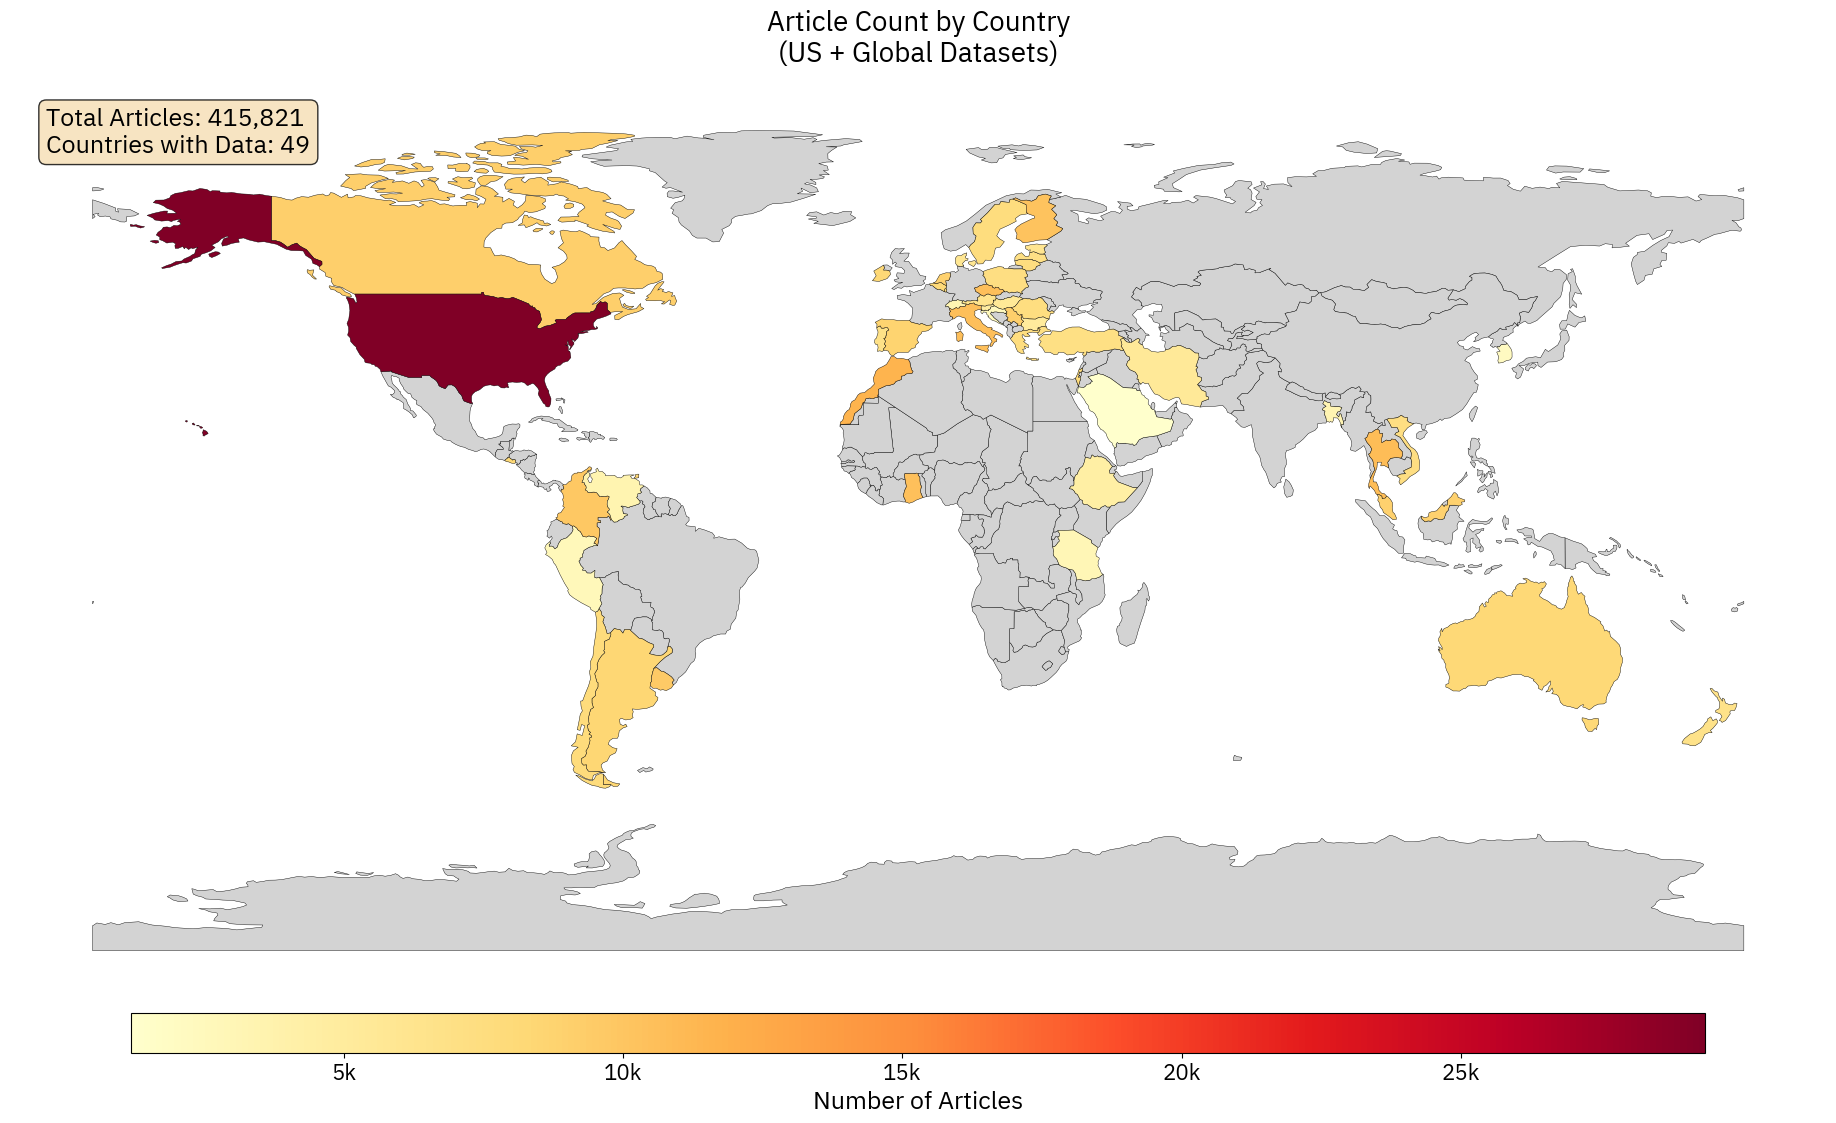

In [23]:
# Create the world map visualization
fig, ax = plt.subplots(1, 1, figsize=(20, 12))

# Separate countries with and without articles
world_with_articles = world_merged[world_merged['article_count'] > 0].copy()
world_no_articles = world_merged[world_merged['article_count'] == 0].copy()

# First plot countries with 0 articles in grey
if len(world_no_articles) > 0:
    world_no_articles.plot(
        ax=ax,
        color='lightgray',
        edgecolor='black',
        linewidth=0.3,
        label='No data'
    )

# Then plot countries with articles using colormap
legend_obj = None
if len(world_with_articles) > 0:
    world_with_articles.plot(
        column='article_count',
        ax=ax,
        legend=True,
        cmap='YlOrRd',  # Yellow-Orange-Red colormap
        edgecolor='black',
        linewidth=0.3,
        legend_kwds={
            'label': 'Number of Articles',
            'orientation': 'horizontal',
            'shrink': 0.8,
            'pad': 0.02,
            'aspect': 40,
        }
    )
    # Get the legend and set font sizes
    # Get the colorbar and set font sizes
    cbar = plt.gcf().axes[-1]  # Get the colorbar axis
    if cbar:
        # Set label fontsize (for horizontal colorbars)
        cbar.xaxis.label.set_fontsize(18)
        cbar.tick_params(labelsize=16)  # Legend tick fontsize
        # Format tick labels: 2 sig figs with k notation
        cbar.xaxis.set_major_formatter(colorbar_formatter)
ax.set_title('Article Count by Country\n(US + Global Datasets)', 
             fontsize=20, fontweight='bold', pad=20)
ax.axis('off')

# Add text annotation with total counts
total_articles = country_counts['article_count'].sum()
total_countries = (world_merged['article_count'] > 0).sum()
ax.text(0.02, 0.98, 
        f'Total Articles: {total_articles:,}\nCountries with Data: {total_countries}',
        transform=ax.transAxes,
        fontsize=18,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()

print(f"\nVisualization complete!")
print(f"Total articles: {total_articles:,}")
print(f"Countries with data: {total_countries}")
print(f"Countries without data: {len(world_no_articles)}")

# Save as PDF
plt.savefig(PROJECT_ROOT / "papers/uair_brief/figures/world_map_articles_count.pdf", dpi=300, bbox_inches='tight')
# Save as PNG
plt.savefig(PROJECT_ROOT / "papers/uair_brief/figures/world_map_articles_count.png", dpi=300, bbox_inches='tight')


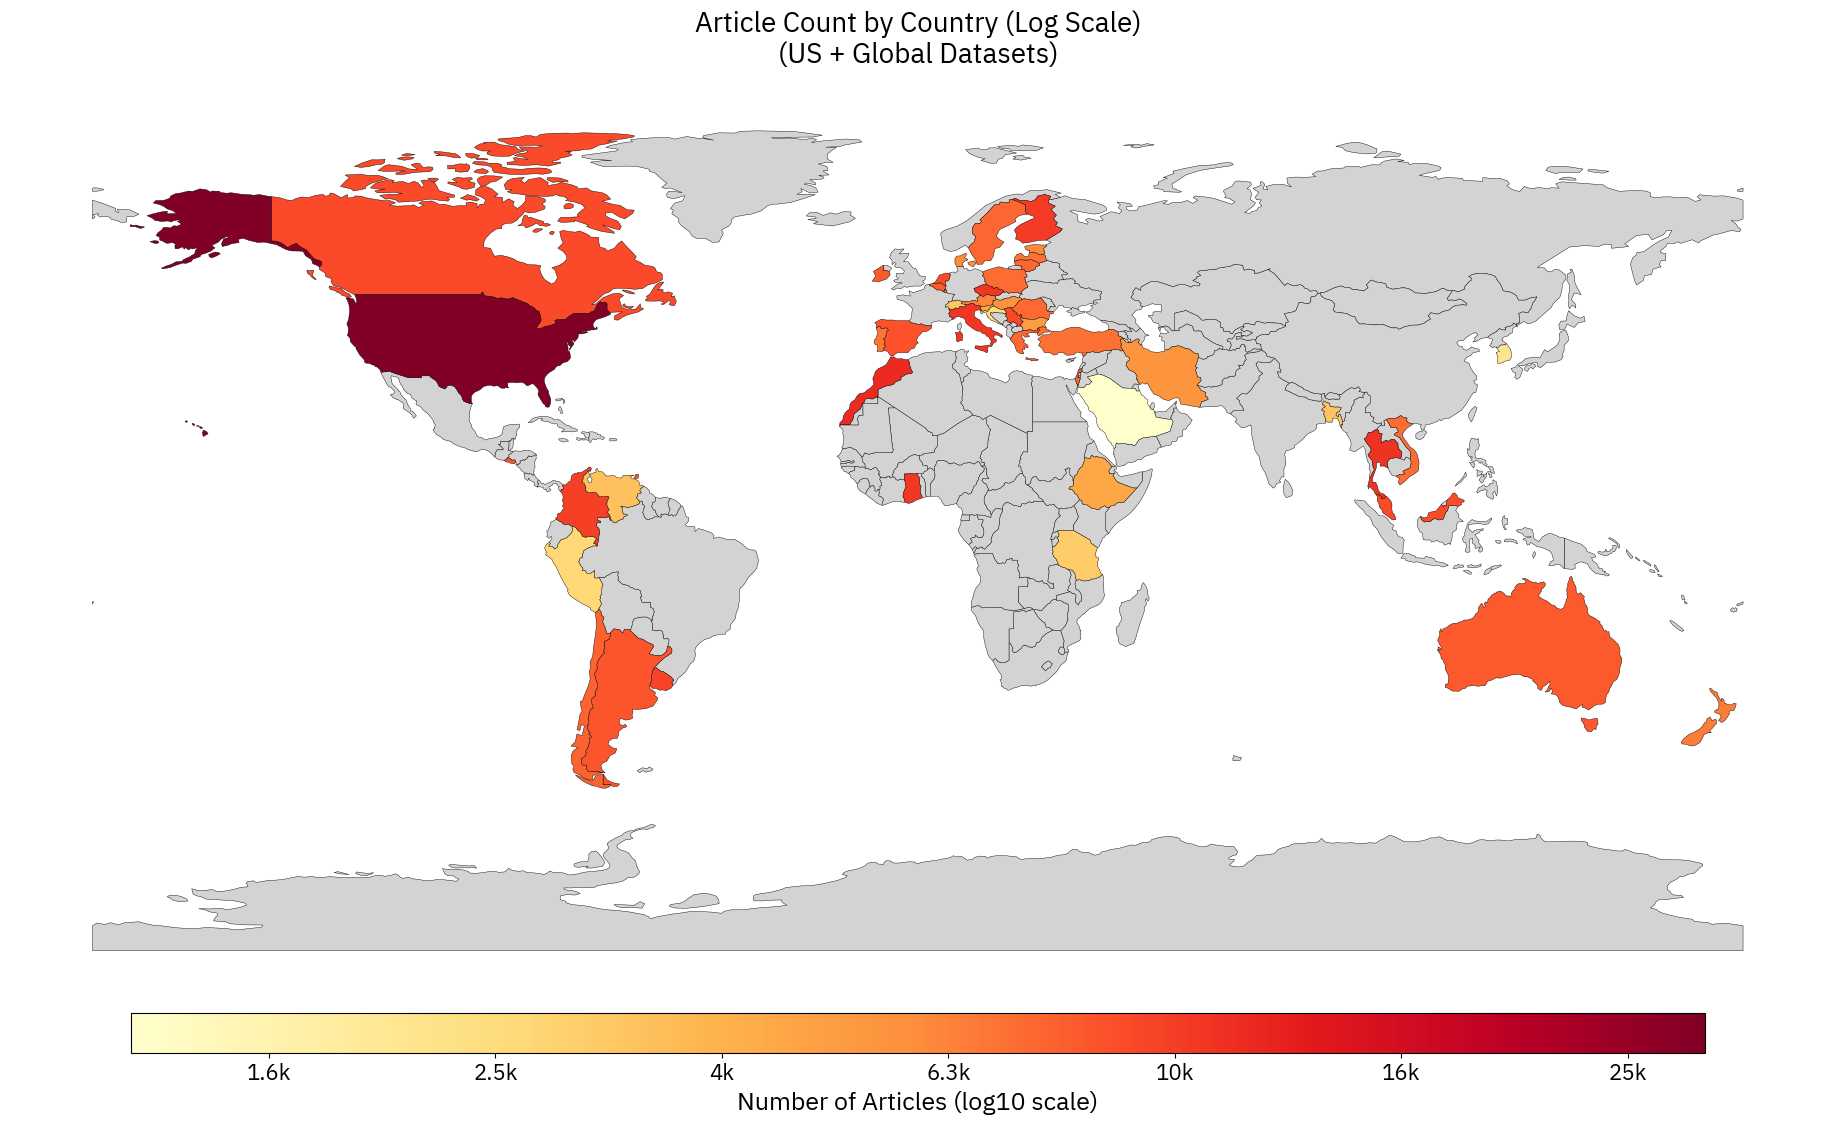

In [24]:
# Create a more detailed visualization with log scale for better contrast
fig, ax = plt.subplots(1, 1, figsize=(20, 12))

# Separate countries with and without articles
world_with_articles = world_merged[world_merged['article_count'] > 0].copy()
world_no_articles = world_merged[world_merged['article_count'] == 0].copy()

# First plot countries with 0 articles in grey
if len(world_no_articles) > 0:
    world_no_articles.plot(
        ax=ax,
        color='lightgray',
        edgecolor='black',
        linewidth=0.3,
        label='No data'
    )

# Then plot countries with articles using log scale colormap
if len(world_with_articles) > 0:
    # Use log scale for better visualization of wide range
    world_with_articles['article_count_log'] = np.log10(world_with_articles['article_count'])
    
    world_with_articles.plot(
        column='article_count_log',
        ax=ax,
        legend=True,
        cmap='YlOrRd',
        edgecolor='black',
        linewidth=0.3,
        legend_kwds={
            'label': 'Number of Articles (log10 scale)',
            'orientation': 'horizontal',
            'shrink': 0.8,
            'pad': 0.02,
            'aspect': 40
        }
    )
    # Get the legend and set font sizes
    # Get the colorbar and set font sizes
    cbar = plt.gcf().axes[-1]  # Get the colorbar axis
    if cbar:
        # Set label fontsize (for horizontal colorbars)
        cbar.xaxis.label.set_fontsize(18)
        cbar.tick_params(labelsize=16)  # Legend tick fontsize
        # Format tick labels: 2 sig figs with k notation
        # Format tick labels: convert log10 to actual counts, then 2 sig figs with k notation
        cbar.xaxis.set_major_formatter(log_colorbar_formatter)
ax.set_title('Article Count by Country (Log Scale)\n(US + Global Datasets)', 
             fontsize=20, fontweight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


Relevant articles: 8,609 out of 415,821 total

Countries with relevant articles: 55

Top 20 countries by relevant article count:
country  article_count iso_a2
     us            578     US
     it            561     IT
     vn            469     VN
     fi            466     FI
     lu            331     LU
     co            299     CO
     gr            286     GR
     sg            282     SG
     hk            256     HK
     tw            249     TW
     fr            227     FR
     bg            224     BG
     th            213     TH
     ro            209     RO
     au            200     AU
     be            198     BE
     se            186     SE
     il            179     IL
     ch            178     CH
     nl            178     NL

Visualization complete!
Total relevant articles: 8,609
Countries with relevant articles: 49
Countries without relevant articles: 128


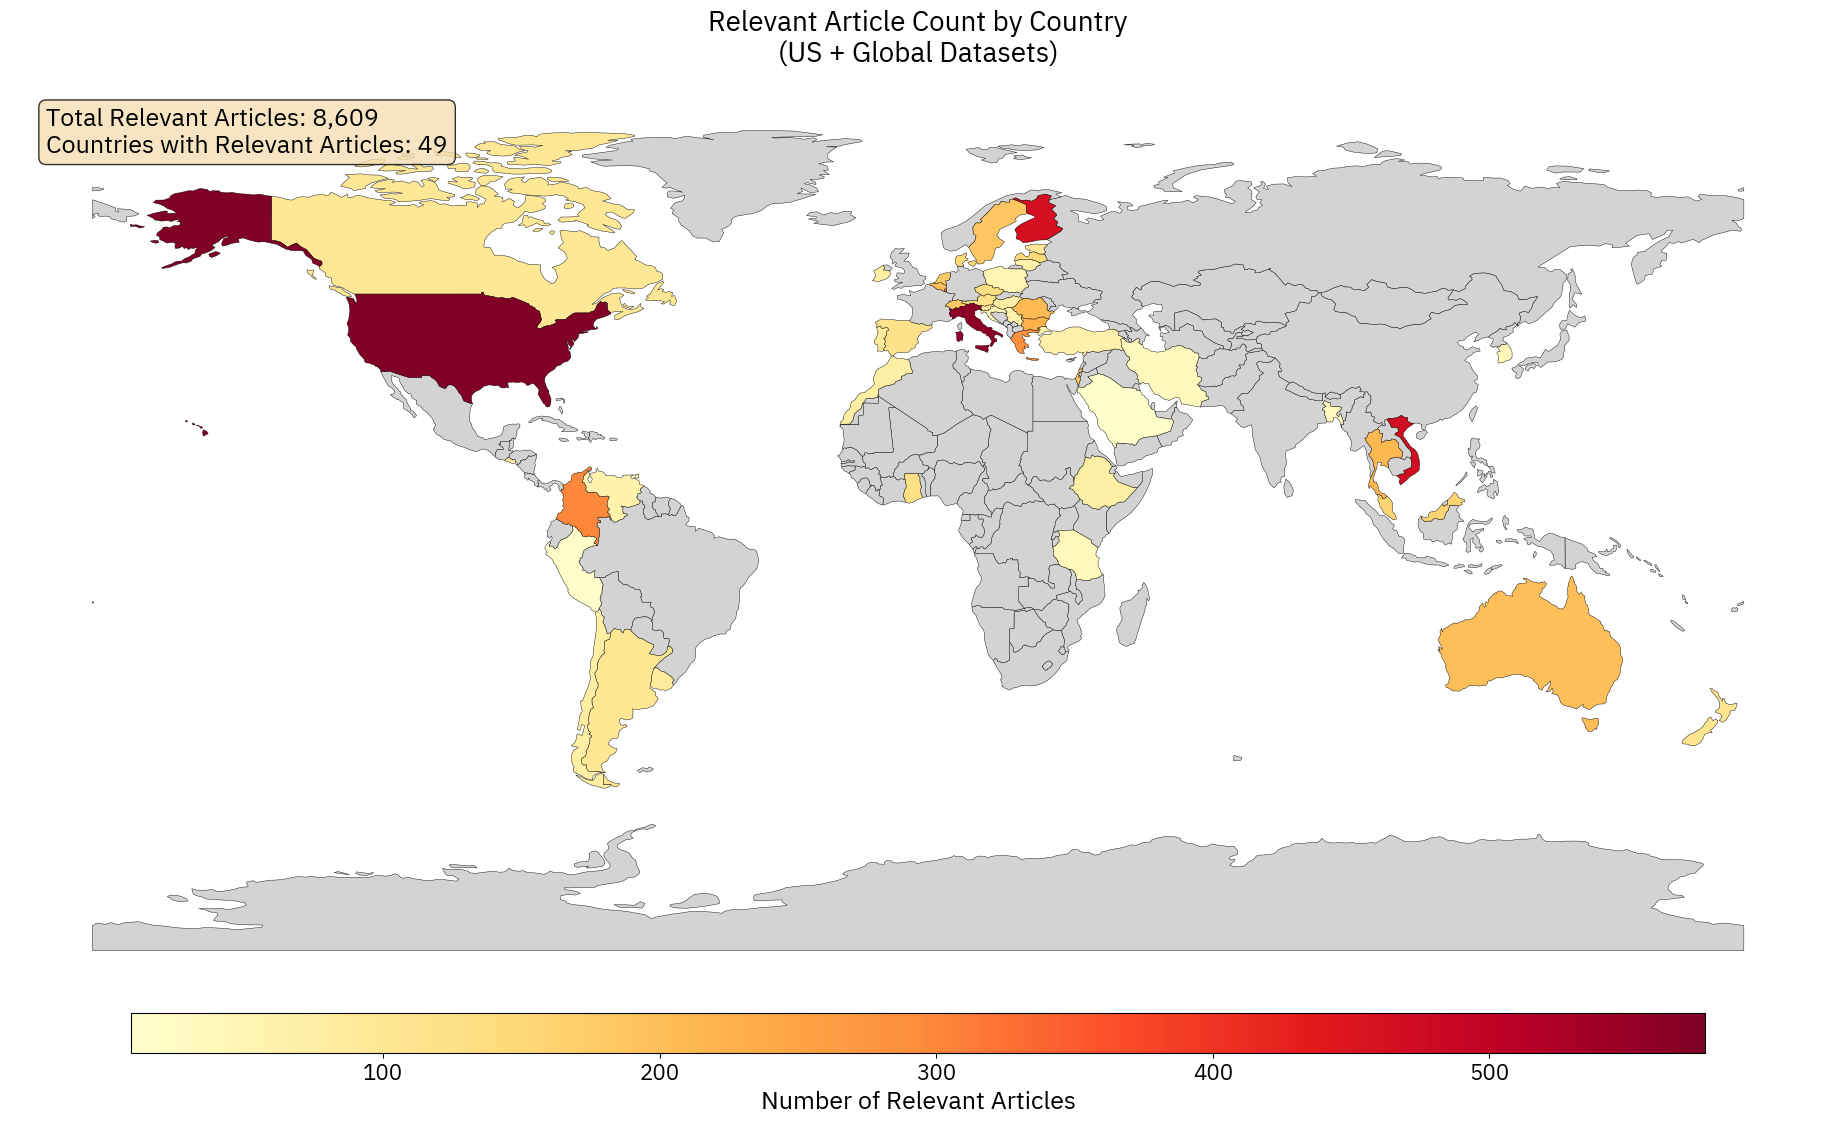

In [25]:
# Create world map visualization for RELEVANT articles only
fig, ax = plt.subplots(1, 1, figsize=(20, 12))

# Filter to relevant articles only
df_relevant = df_combined[df_combined['is_relevant'] == True].copy()
print(f"Relevant articles: {len(df_relevant):,} out of {len(df_combined):,} total")

# Group by country and count relevant articles
country_counts_relevant = df_relevant.groupby('country').size().reset_index(name='article_count')
country_counts_relevant = country_counts_relevant.sort_values('article_count', ascending=False)

# Add ISO codes
country_counts_relevant['iso_a2'] = country_counts_relevant['country'].str.lower().map(COUNTRY_CODE_MAP)

print(f"\nCountries with relevant articles: {len(country_counts_relevant)}")
print("\nTop 20 countries by relevant article count:")
print(country_counts_relevant.head(20).to_string(index=False))

# Merge with world map
world_merged_relevant = world.merge(
    country_counts_relevant,
    left_on='ISO_A2',
    right_on='iso_a2',
    how='left'
)

# Fill NaN article counts with 0
world_merged_relevant['article_count'] = world_merged_relevant['article_count'].fillna(0).astype(int)

# Separate countries with and without relevant articles
world_with_relevant = world_merged_relevant[world_merged_relevant['article_count'] > 0].copy()
world_no_relevant = world_merged_relevant[world_merged_relevant['article_count'] == 0].copy()

# First plot countries with 0 relevant articles in grey
if len(world_no_relevant) > 0:
    world_no_relevant.plot(
        ax=ax,
        color='lightgray',
        edgecolor='black',
        linewidth=0.3,
        label='No relevant articles'
    )

# Then plot countries with relevant articles using colormap
if len(world_with_relevant) > 0:
    world_with_relevant.plot(
        column='article_count',
        ax=ax,
        legend=True,
        cmap='YlOrRd',  # Yellow-Orange-Red colormap
        edgecolor='black',
        linewidth=0.3,
        legend_kwds={
            'label': 'Number of Relevant Articles',
            'orientation': 'horizontal',
            'shrink': 0.8,
            'pad': 0.02,
            'aspect': 40,
        }
    )
    # Get the colorbar and set font sizes
    cbar = plt.gcf().axes[-1]  # Get the colorbar axis
    if cbar:
        # Set label fontsize (for horizontal colorbars)
        cbar.xaxis.label.set_fontsize(18)
        cbar.tick_params(labelsize=16)  # Legend tick fontsize
        # Format tick labels: 2 sig figs with k notation
        cbar.xaxis.set_major_formatter(colorbar_formatter)

ax.set_title('Relevant Article Count by Country\n(US + Global Datasets)', 
             fontsize=20, fontweight='bold', pad=20)
ax.axis('off')

# Add text annotation with total counts
total_relevant = country_counts_relevant['article_count'].sum()
total_countries_relevant = (world_merged_relevant['article_count'] > 0).sum()
ax.text(0.02, 0.98, 
        f'Total Relevant Articles: {total_relevant:,}\nCountries with Relevant Articles: {total_countries_relevant}',
        transform=ax.transAxes,
        fontsize=18,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()

print(f"\nVisualization complete!")
print(f"Total relevant articles: {total_relevant:,}")
print(f"Countries with relevant articles: {total_countries_relevant}")
print(f"Countries without relevant articles: {len(world_no_relevant)}")

# Save as PDF
plt.savefig(PROJECT_ROOT / "papers/uair_brief/figures/world_map_relevant_articles_count.pdf", dpi=300, bbox_inches='tight')
# Save as PNG
plt.savefig(PROJECT_ROOT / "papers/uair_brief/figures/world_map_relevant_articles_count.png", dpi=300, bbox_inches='tight')
plt.show()


Verified tuples: 544 out of 8,609 total

Countries with verified tuples: 54

Top 20 countries by verified tuple count:
country  verified_count iso_a2
     us              61     US
     fi              51     FI
     vn              39     VN
     hk              25     HK
     lu              21     LU
     nl              17     NL
     th              16     TH
     tw              15     TW
     lv              15     LV
     il              14     IL
     au              14     AU
     es              14     ES
     ch              12     CH
     sg              12     SG
     be              12     BE
     gh              11     GH
     mt              11     MT
     se              11     SE
     my              10     MY
     ee              10     EE

Visualization complete!
Total verified tuples: 544
Countries with verified use cases: 48
Countries without verified use cases: 129


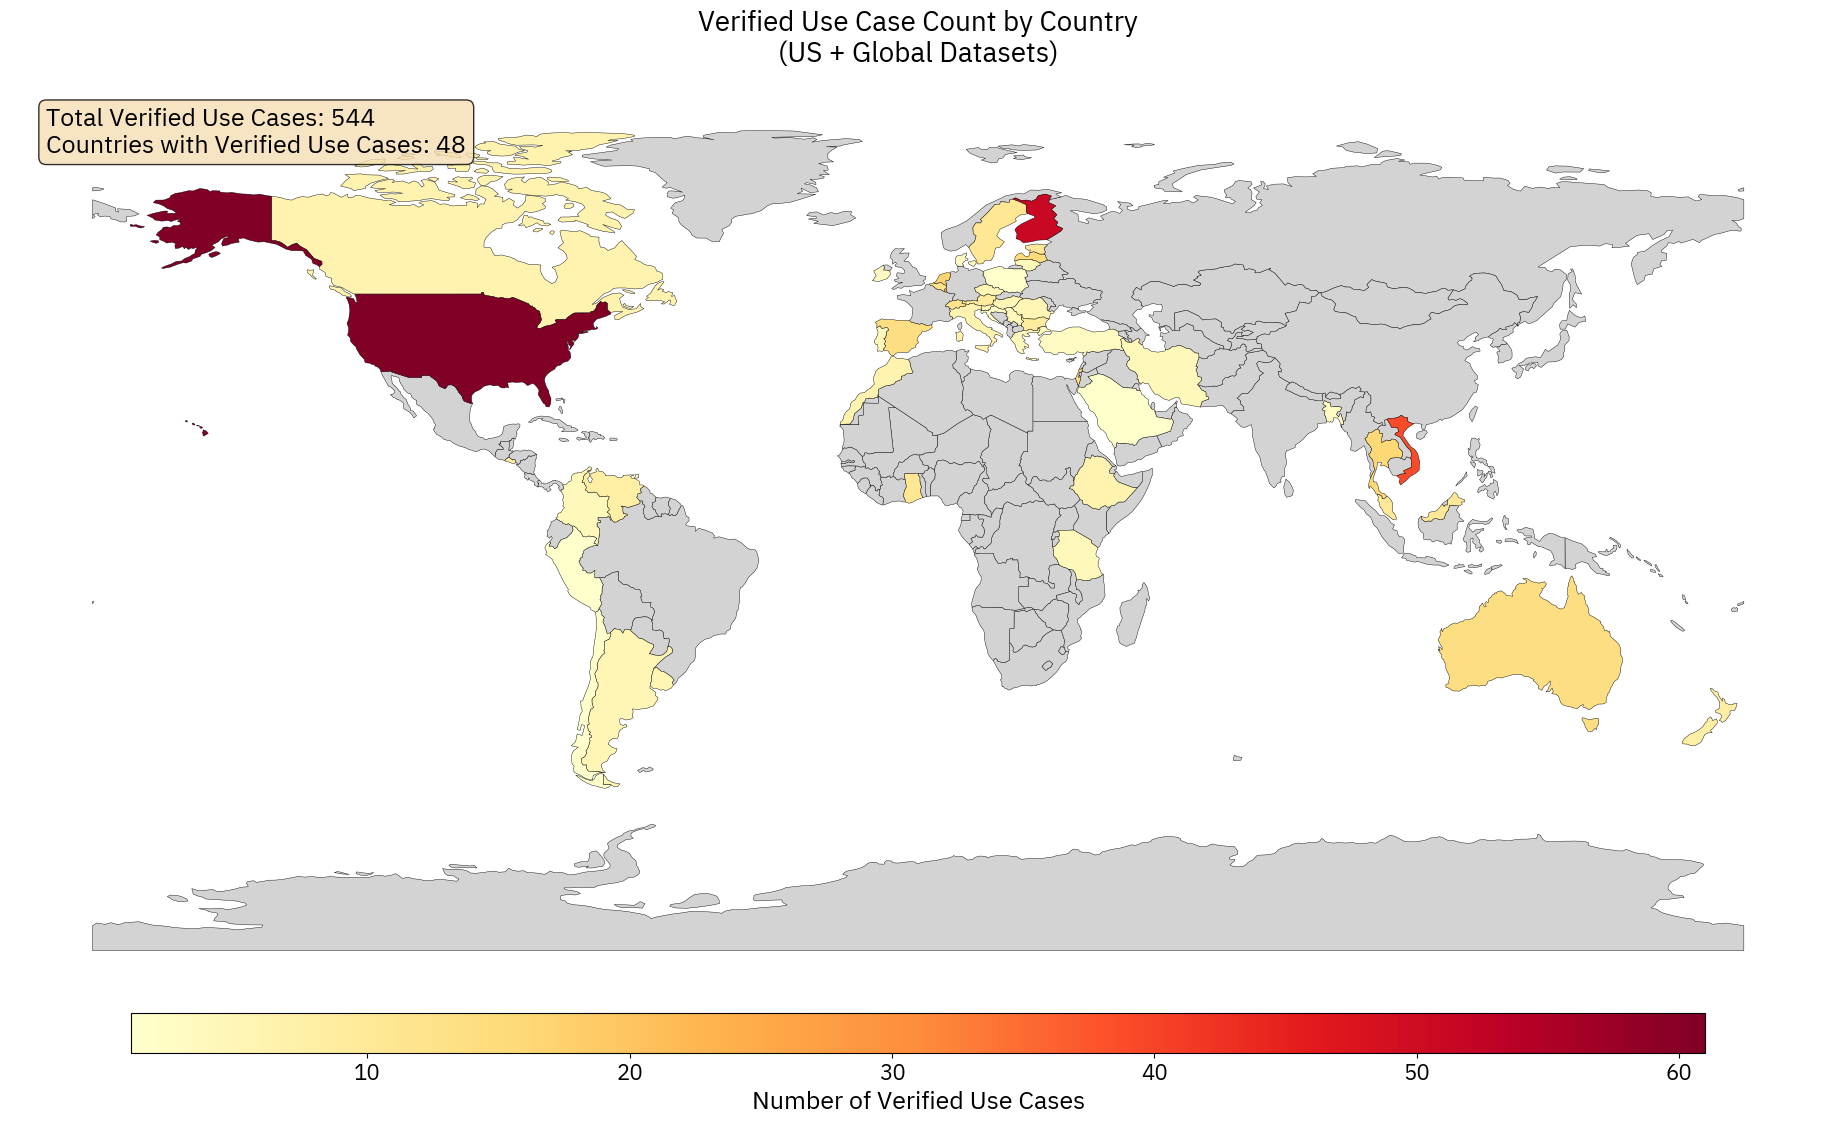

In [ ]:
# Create world map visualization for VERIFIED TUPLES only
fig, ax = plt.subplots(1, 1, figsize=(20, 12))

# Load verify outputs for both US and global datasets
verify_path_us = RESULTS_US_PATH + '/verify_nbl/verify_nbl_results.parquet'
verify_path_global = RESULTS_GLOBAL_PATH + '/verify_nbl/verify_nbl_results.parquet'

df_verify_us = pd.read_parquet(verify_path_us)
df_verify_global = pd.read_parquet(verify_path_global)

df_verify_all = pd.concat([df_verify_us, df_verify_global], ignore_index=True)

# Filter to verified tuples only
df_verified = df_verify_all[df_verify_all['core_tuple_verified'] == True].copy()
print(f"Verified tuples: {len(df_verified):,} out of {len(df_verify_all):,} total")

# Group by country and count verified tuples
country_counts_verified = df_verified.groupby('country').size().reset_index(name='verified_count')
country_counts_verified = country_counts_verified.sort_values('verified_count', ascending=False)

# Add ISO codes
country_counts_verified['iso_a2'] = country_counts_verified['country'].str.lower().map(COUNTRY_CODE_MAP)

print(f"\nCountries with verified tuples: {len(country_counts_verified)}")
print("\nTop 20 countries by verified tuple count:")
print(country_counts_verified.head(20).to_string(index=False))

# Merge with world map
world_merged_verified = world.merge(
    country_counts_verified,
    left_on='ISO_A2',
    right_on='iso_a2',
    how='left'
)

# Fill NaN verified counts with 0
world_merged_verified['verified_count'] = world_merged_verified['verified_count'].fillna(0).astype(int)

# Separate countries with and without verified tuples
world_with_verified = world_merged_verified[world_merged_verified['verified_count'] > 0].copy()
world_no_verified = world_merged_verified[world_merged_verified['verified_count'] == 0].copy()

# First plot countries with 0 verified tuples in grey
if len(world_no_verified) > 0:
    world_no_verified.plot(
        ax=ax,
        color='lightgray',
        edgecolor='black',
        linewidth=0.3,
        label='No verified tuples'
    )

# Then plot countries with verified tuples using colormap
if len(world_with_verified) > 0:
    world_with_verified.plot(
        column='verified_count',
        ax=ax,
        legend=True,
        cmap='YlOrRd',  # Yellow-Orange-Red colormap
        edgecolor='black',
        linewidth=0.3,
        legend_kwds={
            'label': 'Number of Verified Use Cases',
            'orientation': 'horizontal',
            'shrink': 0.8,
            'pad': 0.02,
            'aspect': 40,
        }
    )
    # Get the colorbar and set font sizes
    cbar = plt.gcf().axes[-1]  # Get the colorbar axis
    if cbar:
        # Set label fontsize (for horizontal colorbars)
        cbar.xaxis.label.set_fontsize(18)
        cbar.tick_params(labelsize=16)  # Legend tick fontsize
        # Format tick labels: 2 sig figs with k notation
        cbar.xaxis.set_major_formatter(colorbar_formatter)

ax.set_title('Verified Use Case Count by Country\n(US + Global Datasets)', 
             fontsize=20, fontweight='bold', pad=20)
ax.axis('off')

# Add text annotation with total counts
total_verified = country_counts_verified['verified_count'].sum()
total_countries_verified = (world_merged_verified['verified_count'] > 0).sum()
ax.text(0.02, 0.98, 
        f'Total Verified Use Cases: {total_verified:,}\nCountries with Verified Use Cases: {total_countries_verified}',
        transform=ax.transAxes,
        fontsize=18,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()

print(f"\nVisualization complete!")
print(f"Total verified tuples: {total_verified:,}")
print(f"Countries with verified use cases: {total_countries_verified}")
print(f"Countries without verified use cases: {len(world_no_verified)}")

# Save as PDF
plt.savefig(PROJECT_ROOT / "papers/uair_brief/figures/world_map_verified_tuples_count.pdf", dpi=300, bbox_inches='tight')
# Save as PNG
plt.savefig(PROJECT_ROOT / "papers/uair_brief/figures/world_map_verified_tuples_count.png", dpi=300, bbox_inches='tight')
plt.show()


In [26]:
# Save summary statistics and generate LaTeX table
output_dir = PROJECT_ROOT / "papers/uair_brief/tables"
output_dir.mkdir(parents=True, exist_ok=True)

# Create a summary table with all countries
summary_table = world_merged[world_merged['article_count'] > 0][
    ['NAME', 'ISO_A2', 'article_count']
].sort_values('article_count', ascending=False).reset_index(drop=True)

# Save CSV
summary_table.to_csv(output_dir / "country_article_counts.csv", index=False)
print(f"Saved summary table to {output_dir / 'country_article_counts.csv'}")

# Split into top 25 and bottom 24
top_25 = summary_table.head(25)
bottom_24 = summary_table.tail(24)

# Generate LaTeX table with two columns side by side
latex_lines = [
    '\\begin{table*}[htbp]',
    '    \\centering',
    '    \\caption{All countries in the UAIR dataset by article count. Left column: top 25 countries; right column: bottom 24 countries.}',
    '    \\label{tab:country_article_counts_all}',
    '    \\begin{tabular}{lcc|lcc}',
    '        \\toprule',
    '        \\multicolumn{3}{c|}{\\textbf{Top 25 Countries}} & \\multicolumn{3}{c}{\\textbf{Bottom 24 Countries}} \\\\',
    '        \\cmidrule(lr){1-3} \\cmidrule(lr){4-6}',
    '        Country & ISO & Count & Country & ISO & Count \\\\',
    '        \\midrule',
]

# Add data rows
max_rows = max(len(top_25), len(bottom_24))
for i in range(max_rows):
    row_parts = []
    
    # Left column (top 25)
    if i < len(top_25):
        country = top_25.iloc[i]['NAME'].replace('&', '\\&')
        iso = top_25.iloc[i]['ISO_A2']
        count = f"{top_25.iloc[i]['article_count']:,}"
        row_parts.append(f"        {country} & {iso} & {count}")
    else:
        row_parts.append("        & &")
    
    row_parts.append(" & ")
    
    # Right column (bottom 24)
    if i < len(bottom_24):
        country = bottom_24.iloc[i]['NAME'].replace('&', '\\&')
        iso = bottom_24.iloc[i]['ISO_A2']
        count = f"{bottom_24.iloc[i]['article_count']:,}"
        row_parts.append(f"{country} & {iso} & {count}")
    else:
        row_parts.append(" & &")
    
    latex_lines.append("".join(row_parts) + " \\\\")

# Close table
latex_lines.extend([
    '        \\bottomrule',
    '    \\end{tabular}',
    '\\end{table*}',
])

# Save LaTeX table
latex_content = '\n'.join(latex_lines)
with open(output_dir / "country_article_counts_all.tex", 'w') as f:
    f.write(latex_content)

print(f"\nSaved LaTeX table to {output_dir / 'country_article_counts_all.tex'}")
print(f"\nTotal countries: {len(summary_table)}")
print(f"Top 25 countries: {len(top_25)}")
print(f"Bottom 24 countries: {len(bottom_24)}")
print(f"\nTop 5 countries:")
print(top_25.head(5).to_string(index=False))
print(f"\nBottom 5 countries:")
print(bottom_24.head(5).to_string(index=False))

Saved summary table to /share/pierson/matt/UAIR/papers/uair_brief/tables/country_article_counts.csv

Saved LaTeX table to /share/pierson/matt/UAIR/papers/uair_brief/tables/country_article_counts_all.tex

Total countries: 49
Top 25 countries: 25
Bottom 24 countries: 24

Top 5 countries:
                    NAME ISO_A2  article_count
United States of America     US          29372
                 Morocco     MA          11617
                Thailand     TH          10867
                   Italy     IT          10583
                 Czechia     CZ          10563

Bottom 5 countries:
      NAME ISO_A2  article_count
Luxembourg     LU           7488
   Romania     RO           7390
    Poland     PL           7315
   Vietnam     VN           7290
    Turkey     TR           7038
